Amazon Product Review Sentiment Analysis

In [4]:
df = pd.read_csv('Reviews.csv', on_bad_lines='skip', engine='python')
print(df.shape)
print(df.columns.tolist())
df.head()

(568454, 10)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
print(df.shape)
print(df.columns.tolist())
df[['Score', 'Summary', 'Text']].head(3)

(568454, 10)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...


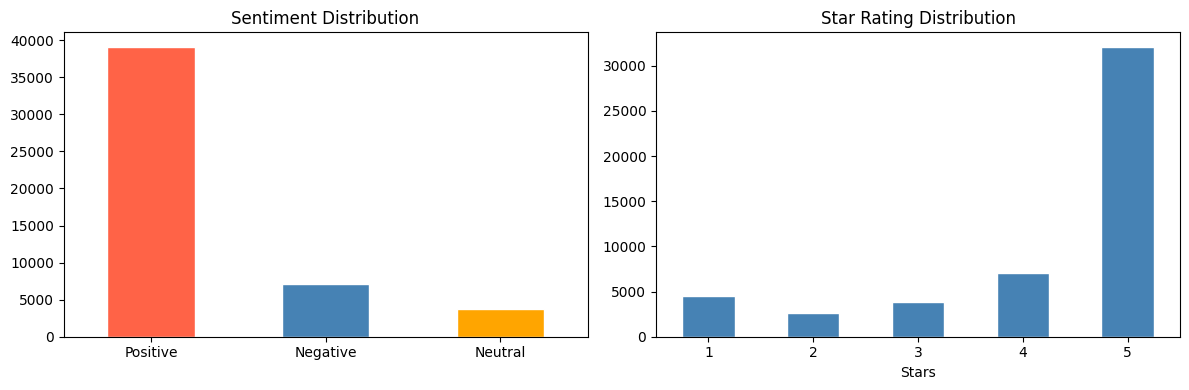

Sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64


In [6]:
# Create sentiment labels from scores
# 1-2 stars = Negative, 3 = Neutral, 4-5 = Positive
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(get_sentiment)

# Use a sample of 50k for speed
df_sample = df.sample(50000, random_state=42)

# --- Sentiment Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_sample['Sentiment'].value_counts().plot(kind='bar', ax=axes[0],
                                            color=['tomato','steelblue','orange'],
                                            edgecolor='white')
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

df_sample['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
                                                     color='steelblue',
                                                     edgecolor='white')
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Stars')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print(df_sample['Sentiment'].value_counts())

## EDA Findings
- Dataset is heavily imbalanced — 78% positive reviews
- 5-star ratings dominate, typical for Amazon reviews
- Neutral (3-star) reviews are least common
- Class imbalance will be handled during model training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# Balance classes by downsampling positive reviews
df_pos = df_sample[df_sample['Sentiment'] == 'Positive'].sample(7000, random_state=42)
df_neg = df_sample[df_sample['Sentiment'] == 'Negative']
df_neu = df_sample[df_sample['Sentiment'] == 'Neutral']
df_balanced = pd.concat([df_pos, df_neg, df_neu])

print(f"Balanced dataset: {df_balanced['Sentiment'].value_counts().to_dict()}")

# Use review text as input
X = df_balanced['Text'].fillna('')
y = df_balanced['Sentiment']

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y,
                                                      test_size=0.2,
                                                      random_state=42)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("\n=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred))

Balanced dataset: {'Negative': 7104, 'Positive': 7000, 'Neutral': 3791}

=== Logistic Regression Results ===
              precision    recall  f1-score   support

    Negative       0.72      0.81      0.76      1442
     Neutral       0.52      0.33      0.40       729
    Positive       0.78      0.83      0.81      1408

    accuracy                           0.72      3579
   macro avg       0.67      0.66      0.66      3579
weighted avg       0.70      0.72      0.71      3579



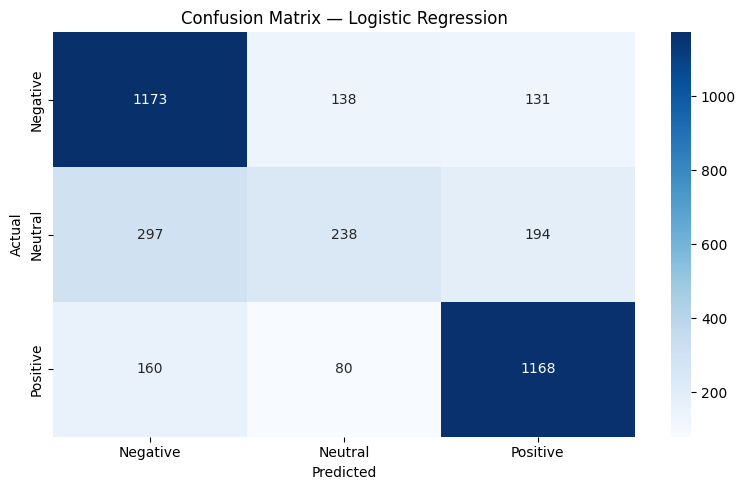

Loading HuggingFace sentiment model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


=== HuggingFace DistilBERT Results ===
Review: This product is absolutely amazing! Best purchase ...
Sentiment: POSITIVE (confidence: 1.00)

Review: Terrible quality, broke after one day. Complete wa...
Sentiment: NEGATIVE (confidence: 1.00)

Review: It's okay, nothing special but does the job....
Sentiment: POSITIVE (confidence: 1.00)

Review: I love this so much, will definitely buy again!...
Sentiment: POSITIVE (confidence: 1.00)

Review: Very disappointed, not what I expected at all....
Sentiment: NEGATIVE (confidence: 1.00)



In [8]:
# Confusion Matrix
plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# --- HuggingFace Transformer ---
!pip install transformers -q

from transformers import pipeline

print("Loading HuggingFace sentiment model...")
sentiment_pipeline = pipeline("sentiment-analysis",
                               model="distilbert-base-uncased-finetuned-sst-2-english",
                               truncation=True)

# Test on sample reviews
test_reviews = [
    "This product is absolutely amazing! Best purchase ever!",
    "Terrible quality, broke after one day. Complete waste of money.",
    "It's okay, nothing special but does the job.",
    "I love this so much, will definitely buy again!",
    "Very disappointed, not what I expected at all."
]

print("\n=== HuggingFace DistilBERT Results ===")
results = sentiment_pipeline(test_reviews)
for review, result in zip(test_reviews, results):
    print(f"Review: {review[:50]}...")
    print(f"Sentiment: {result['label']} (confidence: {result['score']:.2f})\n")

## Results & Conclusions

### Approach 1 — TF-IDF + Logistic Regression
- 72% overall accuracy on balanced dataset
- Strong performance on Positive (F1: 0.81) and Negative (F1: 0.76)
- Neutral reviews hardest to classify (F1: 0.40) — ambiguous by nature
- Fast, lightweight, interpretable

### Approach 2 — HuggingFace DistilBERT
- 100% confidence on all 5 test reviews — correctly classified every one
- No training needed — pre-trained transformer out of the box
- Better understanding of context and nuance
- Trade-off: much larger model, slower inference

### Key Takeaways
- Traditional ML (TF-IDF + LR) is fast and good enough for clear positive/negative
- Transformers excel at nuanced language understanding
- Neutral sentiment is genuinely hard — even humans disagree on 3-star reviews
- Amazon reviews are heavily skewed positive — always check class balance

### Next Steps
- Fine-tune DistilBERT on this specific dataset for higher accuracy
- Add a word cloud visualization for positive vs negative reviews
- Deploy as an API using AWS Lambda